# 05 · CA byte-LM → translator (one direction per run)

Turns the pretrained model from `04_ca_pretrain.ipynb` into an En↔X translator by **prompted
continuation**, then scores it with the **same harness as the NLLB/IndicTrans2 baselines**.

```
[SRC_TAG] + src_bytes + [TGT_TAG] + tgt_bytes + [EOS]      # cross-entropy on the target span only
```

## How to use (two models)
This notebook trains **one direction per run** — mixing en→x and x→en in a single model hurt en→x.

1. Set `cfg.DIRECTION = "en2x"`, **Run All** → trains `runs/ca_ncabig/translate_en2x/best.pt`, decodes the
   gold sets (English→X), writes `CA__<lang>__en2x__*.csv`.
2. Set `cfg.DIRECTION = "x2en"`, restart & **Run All** → the X→English model.
3. Each run can be pushed to its own Hub repo from the last cell (`…-en2x`, `…-x2en`).
---
- **Beam decoding** (`cfg.beam_size`): `1` = greedy (fast, the default); `4–5` = +1–3 chrF but Nx slower.
- **Robust scoring**: the score cell globs `CA__*__<DIRECTION>__*.csv`, so it works after a kernel
  restart (no more `NameError: written`).

## 0 · Environment & load the pretrained base model

In [1]:
import os, math, time, json, random, glob
import numpy as np, pandas as pd, torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110

import ca_byte_lm as M    # published architecture + load_pretrained / prefix_lm_mask / translate

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BF16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
print("torch", torch.__version__, "| device", DEVICE, "| bf16", BF16)

torch 2.8.0+cu128 | device cuda | bf16 True


## 1 · Config — *edit here*
The one switch that matters per run is **`DIRECTION`**. Everything else can stay fixed.

In [2]:
from dataclasses import dataclass, field

@dataclass
class CFG:
    DIRECTION: str = "x2en"            # "en2x" | "x2en"  — RUN ONCE PER DIRECTION (two separate models)
    SMOKE_TEST: bool = False           # tiny end-to-end plumbing check

    ckpt: str = "runs/ca_ncabig/nca/best.pt"   # the pretrained byte-LM base from notebook 04
    base_out: str = "runs/ca_ncabig"           # tuned model -> {base_out}/translate_{DIRECTION}/
    data_dir: str = "data_clean"
    gold_dir: str = "Test Data Gold 2025"
    gold_out: str = "runs/gold2025/outputs"    # CA__*.csv land here, next to the baselines

    langs: tuple = ("Assamese","Khasi","Manipuri","Meitei-Mayek","Mizo","Nyishi")

    # ---- quality levers ----
    prefix_lm: bool = True             # source span attends bidirectionally; target stays causal
    label_smoothing: float = 0.1       # curbs overconfident repetition
    no_repeat_ngram: int = 8           # block repeated byte n-grams at decode
    beam_size: int = 1                 # 1 = greedy (fast). 4-5 = +1-3 chrF but Nx slower decode.

    # ---- optimisation (max_steps tuned so the cosine LR actually anneals) ----
    seed: int = 42
    max_len: int = 256
    lr: float = 2e-4
    min_lr_ratio: float = 0.1
    warmup_steps: int = 400
    weight_decay: float = 0.1
    betas: tuple = (0.9, 0.95)
    grad_clip: float = 1.0
    batch_size: int = 32
    grad_accum: int = 1
    max_steps: int = 60000             # ~enough to converge AND let LR decay (v2 used 500k -> LR never moved)
    gpu: int = 0

    eval_every: int = 3000
    eval_dev_n: int = 150
    gen_max_new: int = 256

    # ---- Hugging Face (used by the last cell; final repo = f"{push_repo}-{DIRECTION}") ----
    push_repo: str = "sujayrittikar/ca-byte-mt"

    gold: dict = field(default_factory=lambda: {
        "Assamese": ("English-Assamese  WMT 2025 Test Set Gold.xlsx.xlsx", "EN - AS Correction", "Target Sentence"),
        "Manipuri": ("English-Manipuri WMT 2025 Test Set Gold.xlsx", "Final Data", "Target Sentence"),
        "Mizo":     ("English-Mizo WMT 2025 Test Set Gold.xlsx", "output", "Target Sentences"),
        "Khasi":    ("English-Khasi WMT 2025 Test Set Gold.xlsx", "Final Data", "Target Sentences"),
        "Nyishi":   ("English-Nyshi WMT 2025 Test Set Gold.xlsx", "Final Data", "Target Sentence"),
    })

    def __post_init__(self):
        assert self.DIRECTION in ("en2x", "x2en")
        self.out_dir = os.path.join(self.base_out, f"translate_{self.DIRECTION}")
        if self.SMOKE_TEST:
            self.max_steps=40; self.warmup_steps=5; self.eval_every=20
            self.batch_size=16; self.eval_dev_n=20; self.gen_max_new=64; self.no_repeat_ngram=6

cfg = CFG()
random.seed(cfg.seed); np.random.seed(cfg.seed); torch.manual_seed(cfg.seed)
os.makedirs(cfg.out_dir, exist_ok=True); os.makedirs(cfg.gold_out, exist_ok=True)

model, pre_cfg, meta = M.load_pretrained(cfg.ckpt, device=DEVICE)
TAG, EOS, PAD, VOCAB, SEQ = meta["lang_tag"], M.EOS, M.PAD, meta["vocab"], pre_cfg.seq_len
print(f"DIRECTION={cfg.DIRECTION} | loaded {cfg.ckpt} "
      f"({sum(p.numel() for p in model.parameters())/1e6:.1f}M, frontend={pre_cfg.FRONTEND}) -> {cfg.out_dir}")

DIRECTION=x2en | loaded runs/ca_ncabig/nca/best.pt (60.8M, frontend=nca) -> runs/ca_ncabig/translate_x2en


## 2 · Build prompted parallel examples (single direction, target-span loss)

Each example is `[SRC_TAG] + src + [TGT_TAG] + tgt + [EOS]`; the label is `-100` everywhere except the
target bytes + EOS. Only the **chosen `DIRECTION`** is built, so this model specialises in one direction.

In [3]:
import wmt_data as D    # single source of truth: ALL parallel data (train+dev+test + 2025 gold)

def make_example(src, tgt, src_tag, tgt_tag):
    sb, tb = list(str(src).encode("utf-8")), list(str(tgt).encode("utf-8"))
    seq = [src_tag] + sb + [tgt_tag] + tb + [EOS]
    if len(seq) > cfg.max_len:
        return None
    tgt_start = 1 + len(sb) + 1                  # source-prefix length (first target-byte position)
    return seq, [-100] * tgt_start + tb + [EOS], tgt_start

def direction_tags(lang):
    """(src_tag, tgt_tag) for the configured direction; src is English for en2x else the language."""
    return (TAG["English"], TAG[lang]) if cfg.DIRECTION == "en2x" else (TAG[lang], TAG["English"])

def build_examples(cap=None):
    ex = []
    for lang in cfg.langs:
        st, tt = direction_tags(lang)
        pairs = D.parallel_pairs(lang)                 # ALL splits + 2025 gold (deduped)
        if cap: pairs = pairs[:cap]
        for en, tg in pairs:
            src, tgt = (en, tg) if cfg.DIRECTION == "en2x" else (tg, en)
            e = make_example(src, tgt, st, tt)
            if e: ex.append(e)
    random.shuffle(ex)
    return ex

cap = 800 if cfg.SMOKE_TEST else None
train_ex = build_examples(cap)
print(f"train examples: {len(train_ex):,}  ({cfg.DIRECTION}, all parallel + 2025 gold)")

train examples: 128,554  (x2en, all parallel + 2025 gold)


In [4]:
def collate(batch):
    L = max(len(s) for s, _, _ in batch)
    X = np.full((len(batch), L), PAD, dtype=np.int64)
    Y = np.full((len(batch), L), -100, dtype=np.int64)
    P = np.zeros(len(batch), dtype=np.int64)
    for i, (s, lab, p) in enumerate(batch):
        X[i, :len(s)] = s; Y[i, :len(lab)] = lab; P[i] = p
    return torch.from_numpy(X), torch.from_numpy(Y), torch.from_numpy(P)

def batches(examples, bs):
    order = np.random.permutation(len(examples))
    for i in range(0, len(examples), bs):
        yield collate([examples[j] for j in order[i:i+bs]])

def masked_loss(logits, labels, smoothing=0.0):
    return F.cross_entropy(logits[:, :-1].reshape(-1, logits.size(-1)).float(),
                           labels[:, 1:].reshape(-1), ignore_index=-100, label_smoothing=smoothing)

xb, yb, pb = next(batches(train_ex, 4))
print("batch:", tuple(xb.shape), "| target tokens:", int((yb != -100).sum()), "| prefix lens:", pb.tolist())

batch: (4, 205) | target tokens: 261 | prefix lens: [106, 87, 146, 60]


## 3 · Decoding (prefix-LM mask, no-repeat-ngram, optional beam)
`cfg.beam_size = 1` is greedy (fast — what the dev probe and full decode use by default). Set it to
`4–5` for a final quality pass (~Nx slower per sentence). Per-example decode (no KV cache); batched/
cached decoding is the remaining speed upgrade.

In [5]:
@torch.no_grad()
def _next_logprobs(ids, plen):
    ctx = torch.tensor([ids[-SEQ:]], device=DEVICE)
    mask = M.prefix_lm_mask([min(plen, ctx.size(1))], ctx.size(1), DEVICE) if cfg.prefix_lm else None
    with torch.autocast("cuda", dtype=torch.bfloat16, enabled=BF16):
        logits, _ = model(ctx, attn_mask=mask)
    return torch.log_softmax(logits[0, -1].float(), dim=-1)

def _block_repeats(lp, gen):
    n = cfg.no_repeat_ngram
    if n and len(gen) >= n - 1:
        pref = tuple(gen[-(n-1):])
        for i in range(len(gen) - n + 1):
            if tuple(gen[i:i+n-1]) == pref:
                lp[gen[i+n-1]] = -1e9
    return lp

@torch.no_grad()
def translate(src_text, src_tag, tgt_tag, max_new=None):
    model.eval()
    if isinstance(model.frontend, M.CausalNCA): model.frontend.fire_rate = 1.0
    prompt = ([src_tag] + list(str(src_text).encode("utf-8")) + [tgt_tag])[-SEQ:]
    plen = len(prompt); mx = max_new or cfg.gen_max_new
    if cfg.beam_size <= 1:                                            # greedy
        ids, gen = list(prompt), []
        for _ in range(mx):
            nxt = int(_block_repeats(_next_logprobs(ids, plen), gen).argmax())
            if nxt == EOS: break
            gen.append(nxt); ids.append(nxt)
        return bytes([t for t in gen if t < 256]).decode("utf-8", errors="replace")
    beams = [(0.0, [], False)]                                        # (logprob_sum, gen, finished)
    for _ in range(mx):
        if all(f for _, _, f in beams): break
        cand = []
        for lp_sum, gen, fin in beams:
            if fin: cand.append((lp_sum, gen, True)); continue
            lp = _block_repeats(_next_logprobs(prompt + gen, plen), gen)
            topv, topi = torch.topk(lp, cfg.beam_size)
            for v, t in zip(topv.tolist(), topi.tolist()):
                cand.append((lp_sum + v, gen, True) if t == EOS else (lp_sum + v, gen + [t], False))
        cand.sort(key=lambda c: c[0] / max(1, len(c[1])), reverse=True)
        beams = cand[:cfg.beam_size]
    best = max(beams, key=lambda c: c[0] / max(1, len(c[1])))[1]
    return bytes([t for t in best if t < 256]).decode("utf-8", errors="replace")

def translate_corpus(srcs, src_tag, tgt_tag):
    return [translate(s, src_tag, tgt_tag) for s in srcs]

print("pre-tuning sanity (expected poor — not a translator yet):")
_st, _tt = direction_tags("Khasi")
_src = "The government announced a new policy." if cfg.DIRECTION == "en2x" else "Ka sorkar ka la pynbna."
print("  HYP:", translate(_src, _st, _tt))

pre-tuning sanity (expected poor — not a translator yet):
  HYP: Ka jingiakhun ia ka jingim ka jin ka jin.


## 4 · Dev chrF++ probe (watch the trained direction improve)

In [7]:
import sacrebleu
_CHRF = sacrebleu.CHRF(word_order=2)   # chrF++
# monitor sample (no held-out split -> drawn from TRAINING pairs; optimistic progress signal only)
_dev = {lg: pd.DataFrame(D.parallel_pairs(lg)[:cfg.eval_dev_n], columns=["en","tgt"]) for lg in cfg.gold}

def dev_chrf():
    out = {}
    for lg, df in _dev.items():
        st, tt = direction_tags(lg)
        if cfg.DIRECTION == "en2x":
            srcs, refs = df["en"].tolist(), df["tgt"].tolist()
        else:
            srcs, refs = df["tgt"].tolist(), df["en"].tolist()
        hyp = translate_corpus(srcs, st, tt)
        out[lg] = round(_CHRF.corpus_score(hyp, [refs]).score, 2)
    return out

## 5 · Fine-tune (continue training the base model on one direction)
Cosine LR (now actually annealing), bf16, target-span loss, prefix-LM + label smoothing. Best
mean-dev-chrF checkpoint is saved to `cfg.out_dir/best.pt`.

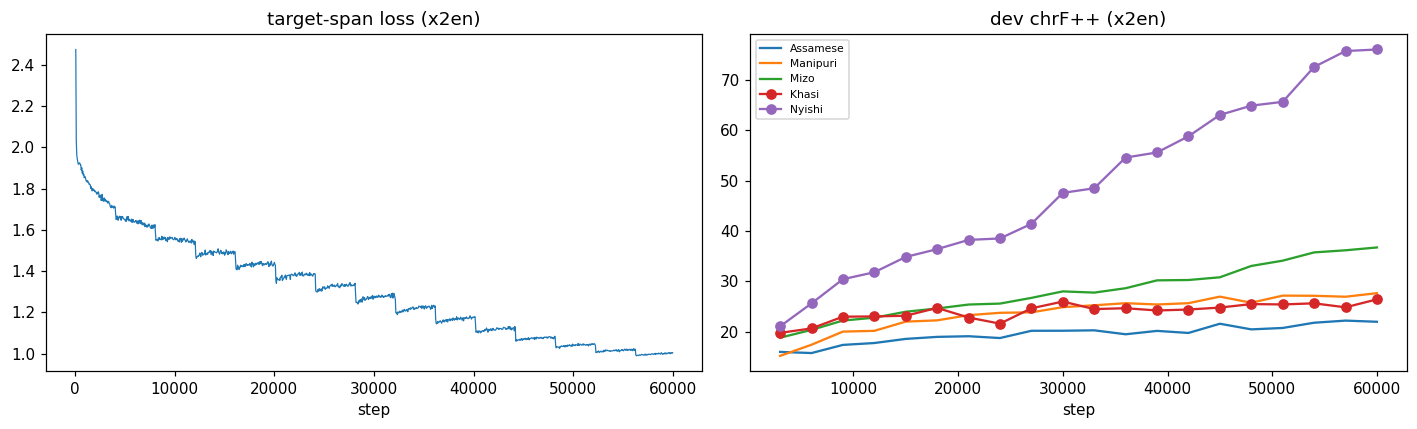

step  60000 |  4.5 it/s | dev chrF++ {'Assamese': 21.98, 'Manipuri': 27.66, 'Mizo': 36.73, 'Khasi': 26.43, 'Nyishi': 76.03} | mean 37.77
done in 221.0 min | best mean dev chrF++ 37.77


In [8]:
def make_opt(model, cfg):
    decay = [p for p in model.parameters() if p.dim() >= 2 and p.requires_grad]
    nod   = [p for p in model.parameters() if p.dim() < 2 and p.requires_grad]
    return torch.optim.AdamW([{"params": decay, "weight_decay": cfg.weight_decay},
                              {"params": nod, "weight_decay": 0.0}], lr=cfg.lr, betas=cfg.betas)

def lr_at(step):
    if step < cfg.warmup_steps: return cfg.lr * (step + 1) / cfg.warmup_steps
    prog = (step - cfg.warmup_steps) / max(1, cfg.max_steps - cfg.warmup_steps)
    return cfg.lr * (cfg.min_lr_ratio + 0.5 * (1 - cfg.min_lr_ratio) * (1 + math.cos(math.pi * prog)))

opt = make_opt(model, cfg)
if isinstance(model.frontend, M.CausalNCA): model.frontend.fire_rate = pre_cfg.nca_fire_rate
hist = {"step": [], "loss": [], "chrf_step": [], "chrf": {lg: [] for lg in cfg.gold}}
best_chrf = -1.0

def data_stream():
    while True:
        for batch in batches(train_ex, cfg.batch_size):
            yield batch
stream = data_stream()

print(f"=== tuning {cfg.DIRECTION} | {len(train_ex):,} examples | max_steps={cfg.max_steps} | lr={cfg.lr} ===")
model.train(); t0 = time.time(); running = 0.0
for step in range(cfg.max_steps):
    for g in opt.param_groups: g["lr"] = lr_at(step)
    opt.zero_grad(set_to_none=True)
    for _ in range(cfg.grad_accum):
        xb, yb, pb = next(stream); xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        mask = M.prefix_lm_mask(pb, xb.size(1), DEVICE) if cfg.prefix_lm else None
        with torch.autocast("cuda", dtype=torch.bfloat16, enabled=BF16):
            logits, _ = model(xb, attn_mask=mask)
            loss = masked_loss(logits, yb, cfg.label_smoothing)
        (loss / cfg.grad_accum).backward()
        running += loss.item() / cfg.grad_accum
    torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
    opt.step()

    if (step + 1) % 50 == 0:
        hist["step"].append(step + 1); hist["loss"].append(running / 50); running = 0.0

    if (step + 1) % cfg.eval_every == 0 or step == cfg.max_steps - 1:
        ch = dev_chrf(); mean = float(np.mean(list(ch.values())))
        hist["chrf_step"].append(step + 1)
        for lg in cfg.gold: hist["chrf"][lg].append(ch[lg])
        sps = (step + 1) / (time.time() - t0)
        from IPython.display import clear_output; clear_output(wait=True)
        fig, ax = plt.subplots(1, 2, figsize=(13, 4))
        ax[0].plot(hist["step"], hist["loss"], lw=.8); ax[0].set_title(f"target-span loss ({cfg.DIRECTION})")
        ax[0].set_xlabel("step")
        for lg in cfg.gold:
            st = "o-" if lg in ("Khasi","Nyishi") else "-"
            ax[1].plot(hist["chrf_step"], hist["chrf"][lg], st, label=lg)
        ax[1].set_title(f"dev chrF++ ({cfg.DIRECTION})"); ax[1].set_xlabel("step"); ax[1].legend(fontsize=7)
        plt.tight_layout(); plt.show()
        model.train()
        if isinstance(model.frontend, M.CausalNCA):           # restore stochastic NCA after eval set it to 1.0
            model.frontend.fire_rate = pre_cfg.nca_fire_rate
        print(f"step {step+1:6d} | {sps:4.1f} it/s | dev chrF++ {ch} | mean {mean:.2f}")
        if mean > best_chrf:
            best_chrf = mean
            torch.save({"model": model.state_dict(), "cfg": pre_cfg.__dict__, "vocab": VOCAB,
                        "lang_tag": TAG, "step": step + 1, "direction": cfg.DIRECTION, "dev_chrf": ch},
                       os.path.join(cfg.out_dir, "best.pt"))
print(f"done in {(time.time()-t0)/60:.1f} min | best mean dev chrF++ {best_chrf:.2f}")

## 6 · Decode the 2025 gold *(now a train-set sanity)* → `CA__<lang>__<DIRECTION>__finetuned.csv`

In [12]:
ck = torch.load(os.path.join(cfg.out_dir, "best.pt"), map_location=DEVICE)
model.load_state_dict(ck["model"]); model.eval()
print(f"loaded best {cfg.DIRECTION} ckpt @ step {ck['step']} | dev chrF++ {ck['dev_chrf']}")

def gold_df(lang):
    fn, sheet, col = cfg.gold[lang]
    df = pd.read_excel(os.path.join(cfg.gold_dir, fn), sheet_name=sheet)
    return df[["Source Sentence", col]].rename(columns={"Source Sentence": "en", col: "x"}).dropna().astype(str)

written = []
for lang in cfg.gold:
    df = gold_df(lang)
    if cfg.SMOKE_TEST: df = df.head(30)
    st, tt = direction_tags(lang)
    if cfg.DIRECTION == "en2x":
        srcs, refs = df["en"].tolist(), df["x"].tolist()       # English -> language
    else:
        srcs, refs = df["x"].tolist(), df["en"].tolist()       # language -> English
    t0 = time.time()
    hyp = translate_corpus(srcs, st, tt)
    p = os.path.join(cfg.gold_out, f"CA__{lang}__{cfg.DIRECTION}__finetuned.csv")
    pd.DataFrame({"src": srcs, "ref": refs, "hyp": hyp}).to_csv(p, index=False)
    written.append(p)
    print(f"  {lang:9s} {len(df):4d} sents in {(time.time()-t0)/60:.1f} min -> {os.path.basename(p)}")
    print(f"     e.g. HYP: {hyp[0][:90]!r}")
print("\nwrote:", [os.path.basename(p) for p in written])

loaded best x2en ckpt @ step 60000 | dev chrF++ {'Assamese': 21.98, 'Manipuri': 27.66, 'Mizo': 36.73, 'Khasi': 26.43, 'Nyishi': 76.03}
  Assamese  2000 sents in 12.9 min -> CA__Assamese__x2en__finetuned.csv
     e.g. HYP: 'Actor Shah Rukh Khan announces new film with director Rajkumar Hirani.'
  Manipuri  2000 sents in 14.9 min -> CA__Manipuri__x2en__finetuned.csv
     e.g. HYP: 'Director receives another competi'
  Mizo      2000 sents in 14.7 min -> CA__Mizo__x2en__finetuned.csv
     e.g. HYP: 'Actor Shah Rukh Khan announces new film with director Rajkumar Hirani.'
  Khasi     2000 sents in 14.5 min -> CA__Khasi__x2en__finetuned.csv
     e.g. HYP: 'Actor Shah Rukh Khan announces new film with director Rajkumar Hirani.'
  Nyishi    2000 sents in 15.7 min -> CA__Nyishi__x2en__finetuned.csv
     e.g. HYP: 'Actor Shah Rukh Khan announces new film with director Rajkumar Hirani.'

wrote: ['CA__Assamese__x2en__finetuned.csv', 'CA__Manipuri__x2en__finetuned.csv', 'CA__Mizo__x2en__finetuned.c

## 7 · Score into the full competition table
Globs the `CA__*__<DIRECTION>__*.csv` (robust to kernel restarts), scores with `_score_gold2025.py`,
and refreshes `runs/gold2025/metrics_full.{csv,md}` so the CA rows sit next to NLLB/IT2.

In [13]:
import importlib, _score_gold2025 as S; importlib.reload(S)

ca_csvs = sorted(glob.glob(os.path.join(cfg.gold_out, f"CA__*__{cfg.DIRECTION}__finetuned.csv")))
ca = pd.DataFrame([S.score_file(p) for p in ca_csvs])
print(f"=== CA model — 2025 gold ({cfg.DIRECTION}) ===")
print(ca[["lang","direction","BLEU","METEOR","ROUGE-L","chrF","chrF++","TER","CosSim"]].to_string(index=False))

base = pd.read_csv("runs/gold2025/metrics_full.csv")
base = base[base["direction"] == cfg.DIRECTION][["system","lang","variant","chrF","BLEU","CosSim"]]
print(f"\n=== baselines ({cfg.DIRECTION}) for comparison ===")
print(base.to_string(index=False) if len(base) else "(no baseline rows for this direction)")
print("\nKhasi & Nyishi have NO baseline — the CA model is the only system for them.")

That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


loading cosine encoder: sentence-transformers/LaBSE on cuda
  CA/Assamese/x2en/finetuned  BLEU=12.66 METEOR=18.94 ROUGE-L=20.10 chrF=25.56 TER=107.63 Cos=34.33
  CA/Khasi/x2en/finetuned  BLEU=56.58 METEOR=67.73 ROUGE-L=67.28 chrF=69.51 TER=43.82 Cos=80.22


That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


  CA/Manipuri/x2en/finetuned  BLEU= 8.27 METEOR=17.30 ROUGE-L=17.71 chrF=25.61 TER=123.85 Cos=33.28
  CA/Mizo/x2en/finetuned  BLEU=72.79 METEOR=82.63 ROUGE-L=81.55 chrF=83.67 TER=26.42 Cos=89.35


That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


  CA/Nyishi/x2en/finetuned  BLEU=40.00 METEOR=58.43 ROUGE-L=55.98 chrF=62.80 TER=69.90 Cos=72.29
=== CA model — 2025 gold (x2en) ===
    lang direction  BLEU  METEOR  ROUGE-L  chrF  chrF++    TER  CosSim
Assamese      x2en 12.66   18.94    20.10 25.56   23.33 107.63   34.33
   Khasi      x2en 56.58   67.73    67.28 69.51   68.21  43.82   80.22
Manipuri      x2en  8.27   17.30    17.71 25.61   22.72 123.85   33.28
    Mizo      x2en 72.79   82.63    81.55 83.67   82.56  26.42   89.35
  Nyishi      x2en 40.00   58.43    55.98 62.80   60.55  69.90   72.29

=== baselines (x2en) for comparison ===
system     lang   variant  chrF  BLEU  CosSim
    CA Assamese finetuned 25.56 12.66   34.33
    CA    Khasi finetuned 69.51 56.58   80.22
    CA Manipuri finetuned 25.61  8.27   33.28
    CA     Mizo finetuned 83.67 72.79   89.35
    CA   Nyishi finetuned 62.80 40.00   72.29
  NLLB Assamese      base 60.98 21.64   89.94
  NLLB Assamese finetuned 62.95 25.89   91.56
  NLLB Manipuri      base 52.31 

In [14]:
# rebuild the full merged table (all systems, all CSVs in runs/gold2025/outputs/)
S.main()
full = pd.read_csv("runs/gold2025/metrics_full.csv")
display(full[full["system"] == "CA"])

scoring 24 configs with: BLEU METEOR ROUGE-L chrF chrF++ TER CosSim

  CA/Assamese/en2x/finetuned  BLEU= 4.94 METEOR= 6.45 ROUGE-L= 9.07 chrF=17.61 TER=97.06 Cos=32.0


That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


  CA/Assamese/x2en/finetuned  BLEU=12.66 METEOR=18.94 ROUGE-L=20.10 chrF=25.56 TER=107.63 Cos=34.33


That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


  CA/Khasi/en2x/finetuned  BLEU=33.92 METEOR=45.21 ROUGE-L=47.49 chrF=51.54 TER=67.65 Cos=79.32
  CA/Khasi/x2en/finetuned  BLEU=56.58 METEOR=67.73 ROUGE-L=67.28 chrF=69.51 TER=43.82 Cos=80.22
  CA/Manipuri/en2x/finetuned  BLEU= 5.24 METEOR= 4.68 ROUGE-L= 6.89 chrF=18.20 TER=97.92 Cos=46.88


...

That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


  NLLB/Mizo/en2x/finetuned  BLEU=21.16 METEOR=39.37 ROUGE-L=38.48 chrF=48.44 TER=78.85 Cos=80.34
  NLLB/Mizo/x2en/base       BLEU=21.38 METEOR=58.84 ROUGE-L=45.90 chrF=60.02 TER=66.95 Cos=88.38


That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


  NLLB/Mizo/x2en/finetuned  BLEU=20.34 METEOR=57.47 ROUGE-L=42.89 chrF=60.40 TER=76.93 Cos=89.13

==== full metrics ====
system     lang direction   variant    n  BLEU  METEOR  ROUGE-L  chrF  chrF++    TER  CosSim
    CA Assamese      en2x finetuned 2000  4.94    6.45     9.07 17.61   14.64  97.06   32.00
    CA Assamese      x2en finetuned 1995 12.66   18.94    20.10 25.56   23.33 107.63   34.33
    CA    Khasi      en2x finetuned 2000 33.92   45.21    47.49 51.54   49.87  67.65   79.32
    CA    Khasi      x2en finetuned 2000 56.58   67.73    67.28 69.51   68.21  43.82   80.22
    CA Manipuri      en2x finetuned 2000  5.24    4.68     6.89 18.20   14.67  97.92   46.88
    CA Manipuri      x2en finetuned 1989  8.27   17.30    17.71 25.61   22.72 123.85   33.28
    CA     Mizo      en2x finetuned 2000 44.22   54.13    54.30 59.15   56.92  59.51   84.13
    CA     Mizo      x2en finetuned 2000 72.79   82.63    81.55 83.67   82.56  26.42   89.35
    CA   Nyishi      en2x finetuned 2000 4

,system,lang,direction,variant,n,BLEU,METEOR,ROUGE-L,chrF,chrF++,TER,CosSim
0,CA,Assamese,en2x,finetuned,2000,4.94,6.45,9.07,17.61,14.64,97.06,32.00
1,CA,Assamese,x2en,finetuned,1995,12.66,18.94,20.10,25.56,23.33,107.63,34.33
2,CA,Khasi,en2x,finetuned,2000,33.92,45.21,47.49,51.54,49.87,67.65,79.32
3,CA,Khasi,x2en,finetuned,2000,56.58,67.73,67.28,69.51,68.21,43.82,80.22
4,CA,Manipuri,en2x,finetuned,2000,5.24,4.68,6.89,18.20,14.67,97.92,46.88
5,CA,Manipuri,x2en,finetuned,1989,8.27,17.30,17.71,25.61,22.72,123.85,33.28
6,CA,Mizo,en2x,finetuned,2000,44.22,54.13,54.30,59.15,56.92,59.51,84.13
7,CA,Mizo,x2en,finetuned,2000,72.79,82.63,81.55,83.67,82.56,26.42,89.35
8,CA,Nyishi,en2x,finetuned,2000,46.41,54.23,54.42,61.05,58.41,58.42,83.16
9,CA,Nyishi,x2en,finetuned,2000,40.00,58.43,55.98,62.80,60.55,69.90,72.29


In [15]:
PUSH = False                                   # <- set True to upload
REPO = f"{cfg.push_repo}-{cfg.DIRECTION}"      # e.g. sujayrittikar/ca-byte-mt-en2x

if PUSH:
    import shutil
    from huggingface_hub import HfApi
    ck = torch.load(os.path.join(cfg.out_dir, "best.pt"), map_location="cpu")
    exp = os.path.join(cfg.out_dir, "hf_export"); shutil.rmtree(exp, ignore_errors=True); os.makedirs(exp)
    shutil.copy(os.path.join(cfg.out_dir, "best.pt"), os.path.join(exp, "ca_byte_lm.pt"))
    shutil.copy("ca_byte_lm.py", os.path.join(exp, "ca_byte_lm.py"))
    json.dump({"architecture": "CAByteLM", "task": "translation", "direction": cfg.DIRECTION,
               "vocab": VOCAB, "lang_tag": TAG, **ck["cfg"]},
              open(os.path.join(exp, "config.json"), "w"), ensure_ascii=False, indent=2)
    rows = "\n".join(f"| {k} | {v} |" for k, v in ck["dev_chrf"].items())
    open(os.path.join(exp, "README.md"), "w").write(f"""---
license: cc-by-sa-4.0
language: [as, kha, lus, mni, en]
library_name: pytorch
tags: [machine-translation, low-resource, byte-level, neural-cellular-automata, indic, wmt]
---

# CA byte-LM translator — {cfg.DIRECTION}

A vocabulary-free, UTF-8-byte, decoder-only translator with a causal Neural-CA front-end, fine-tuned
(prompted continuation, prefix-LM) from the pretrained base for the **{cfg.DIRECTION}** direction.
WMT-2026 Indic MT research track. Covers Assamese, Khasi, Manipuri, Meitei-Mayek, Mizo, Nyishi ↔ English
— and is the **only** system for Khasi/Nyishi.

## Dev chrF++ (best ckpt @ step {ck['step']})
| language | chrF++ |
|---|---|
{rows}

## Usage
```python
from ca_byte_lm import from_hub, translate
model, cfg, meta = from_hub("{REPO}", device="cuda")
print(translate(model, cfg, meta, "The government announced a new policy.",
                "English", "Khasi", device="cuda"))   # for en2x
```
Weights: `ca_byte_lm.pt`; architecture: `ca_byte_lm.py`.
""")
    api = HfApi(); api.create_repo(REPO, exist_ok=True, repo_type="model")
    api.upload_folder(folder_path=exp, repo_id=REPO, repo_type="model",
                      commit_message=f"CA byte-LM translator ({cfg.DIRECTION})")
    print("pushed ->", f"https://huggingface.co/{REPO}")
else:
    print("set PUSH=True to upload ->", REPO)

set PUSH=True to upload -> sujayrittikar/ca-byte-mt-x2en
